# ANN K-Fold Hyperparameter Search
## Anaerobic Digestion of Olive Mill Waste - Crete Case Study

this notebook finds the best hyperparameters for the ANN using K-Fold cross validation

the idea is: instead of training once and hoping for the best, split the data
into K chunks (folds). for each combination of hyperparameters, train on K-1 folds
and validate on the remaining fold, K times. this gives a more reliable estimate of
how the model will generalise to new data

**searching over:**
- H1 and H2 (number of neurons in each hidden layer)
- learning rate
- batch size

**NOT changing:**
- architecture type (still 2 hidden layers, sigmoid, linear output)
- number of epochs (fixed at 100 per fold - fast enough for grid search)
- loss function (MSE)
- optimiser (Adam)

**output:** a table showing avg validation loss for each combination,
pick the best one to use in the final retrain

note: K-Fold on 27,000 rows with a grid search is slow, to keep it manageable used a subset of the data (the clean 1,080 rows from STANDARDISATION_REF) and 6 folds


## 1. Imports and Setup

In [1]:
!pip install tqdm --quiet

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
import copy
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from tqdm import tqdm

torch.manual_seed(1)
np.random.seed(1)

print("imports ok")
print("torch version:", torch.__version__)

imports ok
torch version: 2.11.0


## 2. Load Data

for K-Fold we use the STANDARDISATION_REF sheet (clean 1,080 rows and no noise)
using the noisy 27,000 rows would make the search take forever and the
variance from noise would obscure the hyperparameter signal


In [3]:
book = openpyxl.load_workbook('olive_mill_database.xlsx',
                               read_only=True, data_only=True)

sheet_ref = book['STANDARDISATION_REF']
data_ref  = []
for r in sheet_ref.iter_rows(min_row=4, values_only=True):
    row = [r[c] for c in range(8)]
    data_ref.append(row)

print(f"loaded {len(data_ref)} rows from STANDARDISATION_REF")
print(f"column order: S, M, pH, T, OLR, dS/dt, dM/dt, dpH/dt")

loaded 1080 rows from STANDARDISATION_REF
column order: S, M, pH, T, OLR, dS/dt, dM/dt, dpH/dt


In [4]:
# standardise — fit on same data (its already the reference set)
scaler = StandardScaler()
scaler.fit(data_ref)
standardised = scaler.transform(data_ref)

x_all = standardised[:, 0:5]   # inputs
y_all = standardised[:, 5:8]   # targets

print(f"x_all shape: {x_all.shape}")
print(f"y_all shape: {y_all.shape}")

x_all shape: (1080, 5)
y_all shape: (1080, 3)


## 3. Model Definition

In [5]:
class Net(nn.Module):
    def __init__(self, D_in, H1, H2, D_out):
        super(Net, self).__init__()
        self.linear1 = nn.Linear(D_in, H1)
        self.linear2 = nn.Linear(H1, H2)
        self.linear3 = nn.Linear(H2, D_out)

    def forward(self, x):
        x = torch.sigmoid(self.linear1(x))
        x = torch.sigmoid(self.linear2(x))
        x = self.linear3(x)
        return x

print("Net class defined")

Net class defined


## 4. Define Search Grid

keeping the grid small to run in reasonable time (finer resolution takes more time)
each combination × 6 folds × 100 epochs = quite a lot of training runs,
so to keep the grid focused around sensible ranges based on the first training run


In [6]:
# search grid (add or remove values to change resolution)
h1_values = [10, 15, 20, 25]          # neurons in hidden layer 1
h2_values = [5, 9, 12, 15]            # neurons in hidden layer 2
lr_values = [1e-3, 5e-4, 1e-4]        # learning rates
batch_values = [50, 100, 200]          # batch sizes

n_splits    = 6      # number of K-Fold splits
fold_epochs = 100    # epochs per fold - fast for grid search

total_combos = len(h1_values) * len(h2_values) * len(lr_values) * len(batch_values)
total_runs   = total_combos * n_splits

print(f"H1 values:     {h1_values}")
print(f"H2 values:     {h2_values}")
print(f"LR values:     {lr_values}")
print(f"Batch sizes:   {batch_values}")
print(f"Folds:         {n_splits}")
print(f"Epochs/fold:   {fold_epochs}")
print()
print(f"total combinations: {total_combos}")
print(f"total training runs: {total_runs}  (combinations x folds)")
print()
print("this will take a few minutes — grab a coffee")

H1 values:     [10, 15, 20, 25]
H2 values:     [5, 9, 12, 15]
LR values:     [0.001, 0.0005, 0.0001]
Batch sizes:   [50, 100, 200]
Folds:         6
Epochs/fold:   100

total combinations: 144
total training runs: 864  (combinations x folds)

this will take a few minutes — grab a coffee


## 5. Run the Grid Search

for each combination of H1, H2, lr, batch_size:
1. split the data into 6 folds
2. for each fold: train on 5 folds, validate on 1
3. average the 6 validation losses
4. store the result

reset model weights to the same initial state at the start of each
combination (using deepcopy) so every combination starts from the same
random initialisation to makes the comparison fair


In [7]:
kfold   = KFold(n_splits=n_splits, shuffle=True, random_state=1)
splits  = list(kfold.split(x_all))

results = []   # will hold one dict per combination

combo_count = 0

for H1 in h1_values:
    for H2 in h2_values:
        for lr in lr_values:
            for batch_size in batch_values:

                combo_count += 1

                # build model and save initial weights
                model    = Net(5, H1, H2, 3)
                loss_fn  = nn.MSELoss(reduction='mean')
                optimizer = torch.optim.Adam(model.parameters(), lr=lr)

                # deepcopy saves the initial random state
                # so every fold starts identically
                init_weights = copy.deepcopy(model.state_dict())
                init_optim   = copy.deepcopy(optimizer.state_dict())

                fold_losses = []

                for fold_i, (train_idx, val_idx) in enumerate(splits):

                    # reset to initial weights for each fold
                    model.load_state_dict(init_weights)
                    optimizer.load_state_dict(init_optim)
                    model.train()

                    # prepare fold data
                    x_tr = torch.tensor(x_all[train_idx], dtype=torch.float32)
                    y_tr = torch.tensor(y_all[train_idx], dtype=torch.float32)
                    x_vl = torch.tensor(x_all[val_idx],   dtype=torch.float32)
                    y_vl = torch.tensor(y_all[val_idx],   dtype=torch.float32)

                    # build dataloader for this fold
                    fold_dataset = torch.utils.data.TensorDataset(x_tr, y_tr)
                    fold_loader  = torch.utils.data.DataLoader(
                        fold_dataset, batch_size=batch_size, shuffle=True)

                    # train for fold_epochs
                    for epoch in range(fold_epochs):
                        for x_batch, y_batch in fold_loader:
                            y_pred = model(x_batch)
                            loss   = loss_fn(y_pred, y_batch)
                            optimizer.zero_grad()
                            loss.backward()
                            optimizer.step()

                    # evaluate on validation fold
                    model.eval()
                    with torch.no_grad():
                        val_pred = model(x_vl)
                        val_loss = loss_fn(val_pred, y_vl).item()
                    fold_losses.append(val_loss)

                avg_loss = np.mean(fold_losses)
                std_loss = np.std(fold_losses)

                results.append({
                    'H1': H1, 'H2': H2, 'lr': lr, 'batch': batch_size,
                    'avg_val_loss': avg_loss,
                    'std_val_loss': std_loss,
                    'fold_losses':  fold_losses,
                })

                if combo_count % 10 == 0 or combo_count == total_combos:
                    print(f"[{combo_count}/{total_combos}]  "
                          f"H1={H1:>2} H2={H2:>2} lr={lr:.0e} batch={batch_size:>3}  "
                          f"avg_val_loss={avg_loss:.5f}  std={std_loss:.5f}")

print()
print(f"grid search complete. {len(results)} combinations evaluated.")

[10/144]  H1=10 H2= 9 lr=1e-03 batch= 50  avg_val_loss=0.07763  std=0.01611
[20/144]  H1=10 H2=12 lr=1e-03 batch=100  avg_val_loss=0.13671  std=0.02886
[30/144]  H1=10 H2=15 lr=1e-03 batch=200  avg_val_loss=0.19056  std=0.04092
[40/144]  H1=15 H2= 5 lr=5e-04 batch= 50  avg_val_loss=0.20680  std=0.04838
[50/144]  H1=15 H2= 9 lr=5e-04 batch=100  avg_val_loss=0.26101  std=0.05892
[60/144]  H1=15 H2=12 lr=5e-04 batch=200  avg_val_loss=0.47750  std=0.07913
[70/144]  H1=15 H2=15 lr=1e-04 batch= 50  avg_val_loss=0.79300  std=0.12137
[80/144]  H1=20 H2= 5 lr=1e-04 batch=100  avg_val_loss=1.00980  std=0.13067
[90/144]  H1=20 H2= 9 lr=1e-04 batch=200  avg_val_loss=0.98499  std=0.14084
[100/144]  H1=20 H2=15 lr=1e-03 batch= 50  avg_val_loss=0.02591  std=0.00814
[110/144]  H1=25 H2= 5 lr=1e-03 batch=100  avg_val_loss=0.18651  std=0.04123
[120/144]  H1=25 H2= 9 lr=1e-03 batch=200  avg_val_loss=0.29124  std=0.06971
[130/144]  H1=25 H2=12 lr=5e-04 batch= 50  avg_val_loss=0.10821  std=0.02942
[140/144

## 6. Results - Top 10 Combinations

In [8]:
# sort by average validation loss (lower = better)
results_sorted = sorted(results, key=lambda x: x['avg_val_loss'])

print("TOP 10 COMBINATIONS (sorted by avg validation loss):")
print("-" * 75)
print(f"{'Rank':>4} {'H1':>4} {'H2':>4} {'LR':>8} {'Batch':>6} "
      f"{'Avg Val Loss':>14} {'Std':>10}")
print("-" * 75)

for i, r in enumerate(results_sorted[:10], 1):
    print(f"{i:>4} {r['H1']:>4} {r['H2']:>4} {r['lr']:>8.0e} {r['batch']:>6} "
          f"{r['avg_val_loss']:>14.6f} {r['std_val_loss']:>10.6f}")

print("-" * 75)
best = results_sorted[0]
print(f"\nBEST: H1={best['H1']}, H2={best['H2']}, "
      f"lr={best['lr']:.0e}, batch={best['batch']}")
print(f"      avg val loss = {best['avg_val_loss']:.6f}  "
      f"std = {best['std_val_loss']:.6f}")

TOP 10 COMBINATIONS (sorted by avg validation loss):
---------------------------------------------------------------------------
Rank   H1   H2       LR  Batch   Avg Val Loss        Std
---------------------------------------------------------------------------
   1   20   15    1e-03     50       0.025906   0.008138
   2   25   12    1e-03     50       0.028412   0.011082
   3   25   15    1e-03     50       0.029444   0.009350
   4   20   12    1e-03     50       0.031626   0.010794
   5   15   15    1e-03     50       0.033815   0.009421
   6   15   12    1e-03     50       0.046127   0.013075
   7   20    9    1e-03     50       0.048951   0.015909
   8   25    9    1e-03     50       0.052489   0.015520
   9   10   12    1e-03     50       0.054476   0.015608
  10   10   15    1e-03     50       0.055292   0.013128
---------------------------------------------------------------------------

BEST: H1=20, H2=15, lr=1e-03, batch=50
      avg val loss = 0.025906  std = 0.008138


## 7. Visualise Results

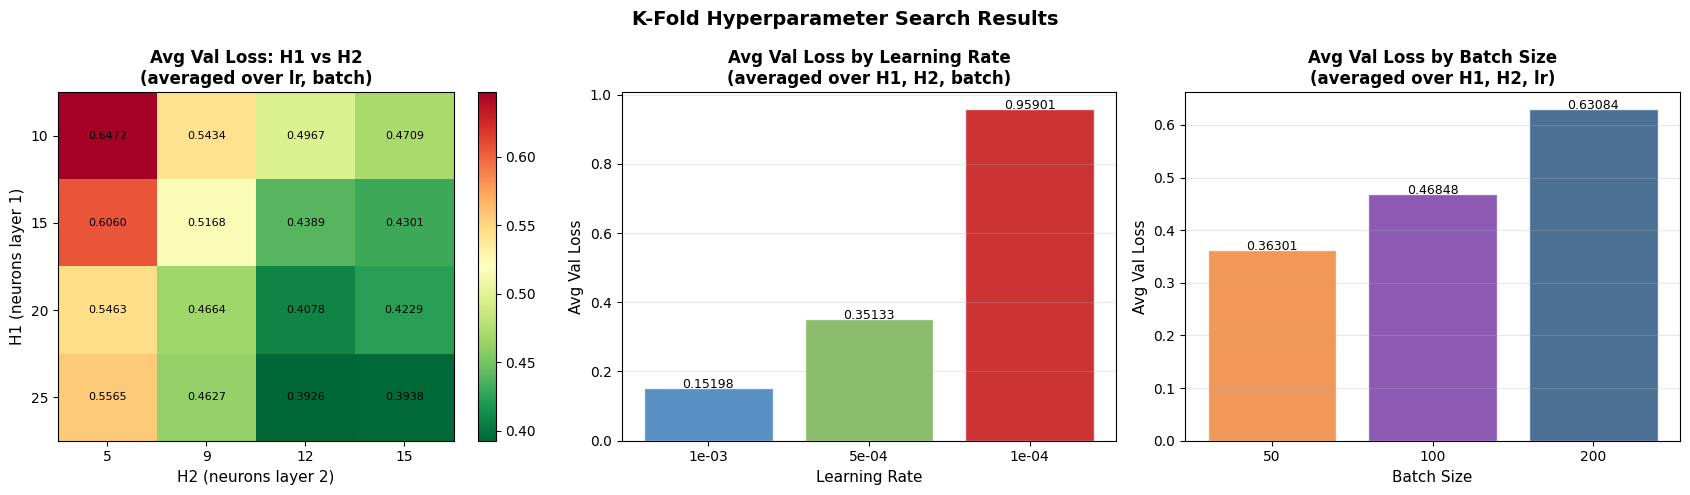

In [9]:
# heatmap: avg val loss for H1 vs H2 (averaged over lr and batch)
import numpy as np

heatmap_data = np.zeros((len(h1_values), len(h2_values)))
for i, h1 in enumerate(h1_values):
    for j, h2 in enumerate(h2_values):
        vals = [r['avg_val_loss'] for r in results
                if r['H1'] == h1 and r['H2'] == h2]
        heatmap_data[i, j] = np.mean(vals)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# left: H1 vs H2 heatmap
im = axes[0].imshow(heatmap_data, cmap='RdYlGn_r', aspect='auto')
axes[0].set_xticks(range(len(h2_values))); axes[0].set_xticklabels(h2_values)
axes[0].set_yticks(range(len(h1_values))); axes[0].set_yticklabels(h1_values)
axes[0].set_xlabel('H2 (neurons layer 2)', fontsize=11)
axes[0].set_ylabel('H1 (neurons layer 1)', fontsize=11)
axes[0].set_title('Avg Val Loss: H1 vs H2\n(averaged over lr, batch)', fontweight='bold')
plt.colorbar(im, ax=axes[0])
for i in range(len(h1_values)):
    for j in range(len(h2_values)):
        axes[0].text(j, i, f'{heatmap_data[i,j]:.4f}',
                    ha='center', va='center', fontsize=8, color='black')

# middle: loss by learning rate
lr_means = []
for lr in lr_values:
    vals = [r['avg_val_loss'] for r in results if r['lr'] == lr]
    lr_means.append(np.mean(vals))
axes[1].bar([f'{lr:.0e}' for lr in lr_values], lr_means,
            color=['#2E75B6','#70AD47','#C00000'], alpha=0.8, edgecolor='white')
axes[1].set_xlabel('Learning Rate', fontsize=11)
axes[1].set_ylabel('Avg Val Loss', fontsize=11)
axes[1].set_title('Avg Val Loss by Learning Rate\n(averaged over H1, H2, batch)',
                   fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(lr_means):
    axes[1].text(i, v + 0.0001, f'{v:.5f}', ha='center', fontsize=9)

# right: loss by batch size
batch_means = []
for b in batch_values:
    vals = [r['avg_val_loss'] for r in results if r['batch'] == b]
    batch_means.append(np.mean(vals))
axes[2].bar([str(b) for b in batch_values], batch_means,
            color=['#ED7D31','#7030A0','#1F4E79'], alpha=0.8, edgecolor='white')
axes[2].set_xlabel('Batch Size', fontsize=11)
axes[2].set_ylabel('Avg Val Loss', fontsize=11)
axes[2].set_title('Avg Val Loss by Batch Size\n(averaged over H1, H2, lr)',
                   fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(batch_means):
    axes[2].text(i, v + 0.0001, f'{v:.5f}', ha='center', fontsize=9)

plt.suptitle('K-Fold Hyperparameter Search Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

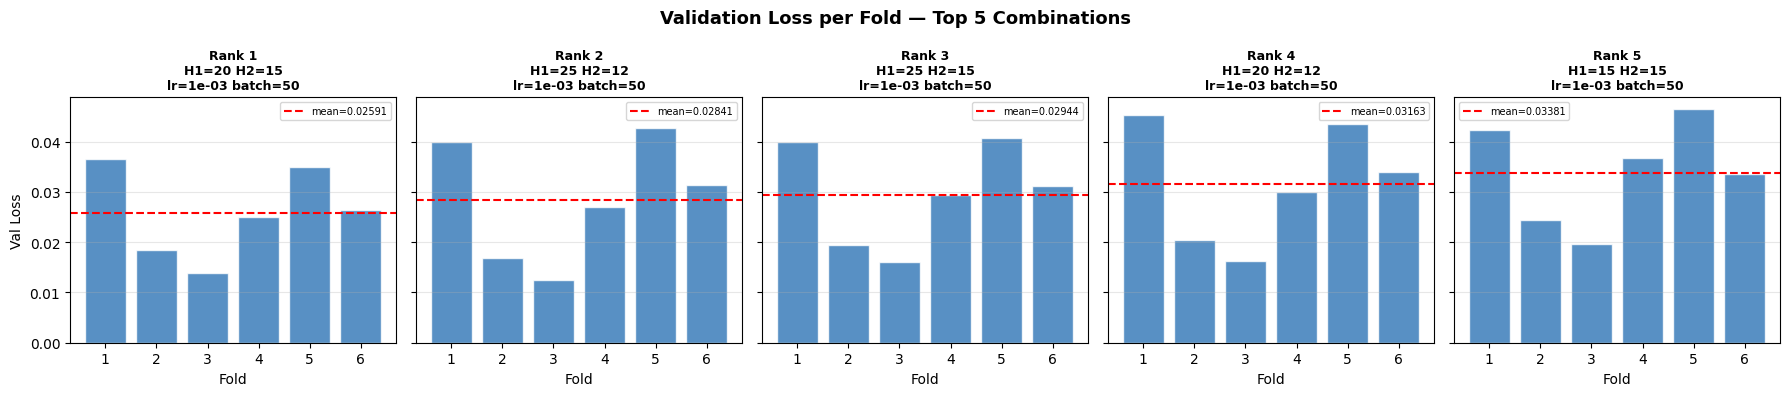

consistent fold losses = model is stable, not just lucky on one fold


In [10]:
# fold-by-fold breakdown for top 5 - shows consistency across folds
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)

for ax, r, rank in zip(axes, results_sorted[:5], range(1, 6)):
    ax.bar(range(1, n_splits+1), r['fold_losses'],
           color='#2E75B6', alpha=0.8, edgecolor='white')
    ax.axhline(r['avg_val_loss'], color='red', linestyle='--',
               linewidth=1.5, label=f"mean={r['avg_val_loss']:.5f}")
    ax.set_title(f"Rank {rank}\nH1={r['H1']} H2={r['H2']}\n"
                 f"lr={r['lr']:.0e} batch={r['batch']}", fontsize=9, fontweight='bold')
    ax.set_xlabel('Fold')
    if rank == 1:
        ax.set_ylabel('Val Loss')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Validation Loss per Fold — Top 5 Combinations',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("consistent fold losses = model is stable, not just lucky on one fold")

## 8. Best Hyperparameters

extract the winning combination and print it clearly so it's easy to copy
into the retrain notebook


In [11]:
best = results_sorted[0]

print("=" * 55)
print("BEST HYPERPARAMETERS FROM K-FOLD SEARCH")
print("=" * 55)
print(f"  H1 (hidden layer 1 neurons): {best['H1']}")
print(f"  H2 (hidden layer 2 neurons): {best['H2']}")
print(f"  Learning rate:               {best['lr']}")
print(f"  Batch size:                  {best['batch']}")
print(f"  Avg validation loss:         {best['avg_val_loss']:.6f}")
print(f"  Std across folds:            {best['std_val_loss']:.6f}")
print("=" * 55)
print()

# compare to what we used in first training run
print("comparison to first training run:")
print(f"  first run:  H1=15, H2=9,  lr=1e-3, batch=100")
print(f"  best found: H1={best['H1']}, H2={best['H2']}, "
      f"lr={best['lr']:.0e}, batch={best['batch']}")
print()
print("use these values in ANN_Retrain_Olive_Mill.ipynb")

BEST HYPERPARAMETERS FROM K-FOLD SEARCH
  H1 (hidden layer 1 neurons): 20
  H2 (hidden layer 2 neurons): 15
  Learning rate:               0.001
  Batch size:                  50
  Avg validation loss:         0.025906
  Std across folds:            0.008138

comparison to first training run:
  first run:  H1=15, H2=9,  lr=1e-3, batch=100
  best found: H1=20, H2=15, lr=1e-03, batch=50

use these values in ANN_Retrain_Olive_Mill.ipynb


## 9. Save Results

In [12]:
import json

save_data = []
for r in results_sorted:
    save_data.append({
        'H1': r['H1'], 'H2': r['H2'],
        'lr': r['lr'], 'batch': r['batch'],
        'avg_val_loss': r['avg_val_loss'],
        'std_val_loss': r['std_val_loss'],
        'fold_losses':  r['fold_losses'],
    })

with open('kfold_results_ANN.json', 'w') as f:
    json.dump(save_data, f, indent=2)

print("results saved to kfold_results_ANN.json")
print()
print("next step: ANN_Retrain_Olive_Mill.ipynb")
print(f"  use H1={best['H1']}, H2={best['H2']}, "
      f"lr={best['lr']:.0e}, batch={best['batch']}")

results saved to kfold_results_ANN.json

next step: ANN_Retrain_Olive_Mill.ipynb
  use H1=20, H2=15, lr=1e-03, batch=50
